In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Sequence

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp

from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import LieTrotter

from qiskit.transpiler import PassManager
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2

from qiskit.primitives import StatevectorEstimator

from qiskit_ibm_runtime import QiskitRuntimeService, Session, EstimatorV2
from qiskit_ibm_runtime.fake_provider import FakeFractionalBackend, FakeGuadalupeV2

import hamiltonian_generator, evolution_circuits

from itertools import product

import warnings
warnings.filterwarnings("ignore")

In [2]:
n, h = 3, 0.5
H = hamiltonian_generator.get_ising_hamiltonian(n, h)
print(H)

Hd = hamiltonian_generator.get_dynamic_ising_hamiltonian(n, h)
print(Hd)

SparsePauliOp(['ZZI', 'IZZ', 'XII', 'IXI', 'IIX'],
              coeffs=[1. +0.j, 1. +0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j])
SparsePauliOp(['IIZZI', 'IIIZZ', 'IIXII', 'IIIXI', 'IIIIX'],
              coeffs=[1. +0.j, 1. +0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j])


In [3]:
final_time = 1
num_timesteps = 20
dt = final_time / num_timesteps

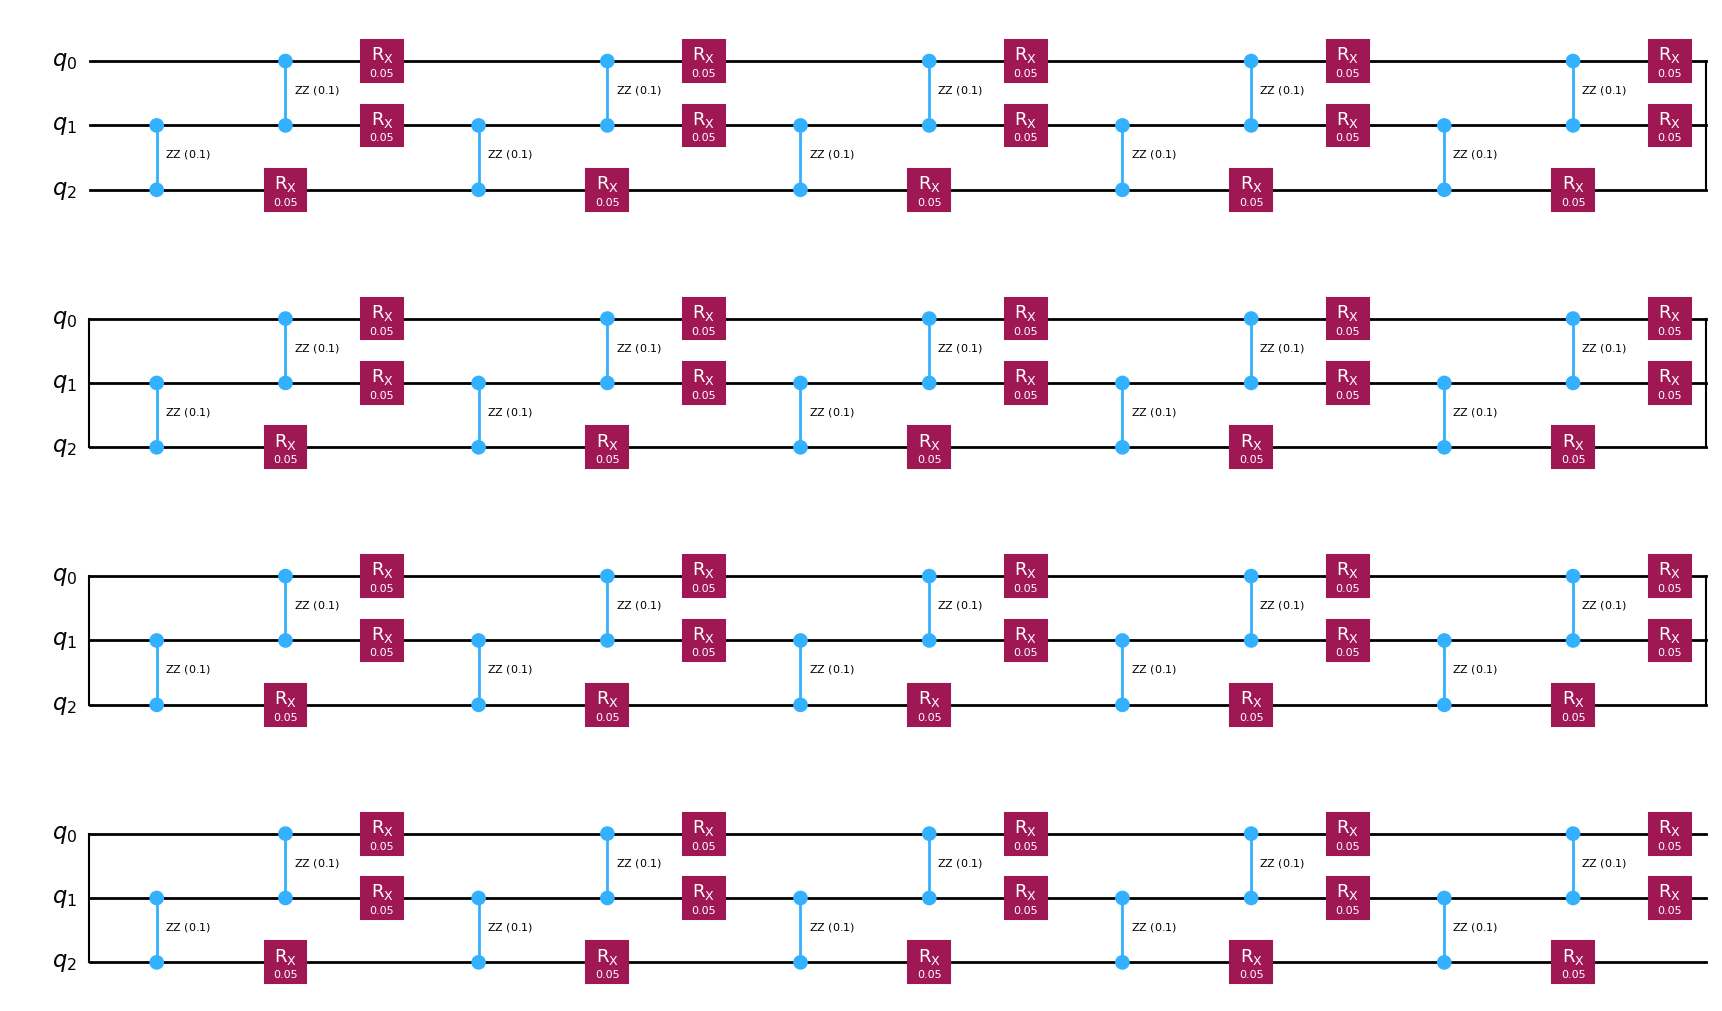

In [4]:
trotter_step = PauliEvolutionGate(H, dt, synthesis=LieTrotter())

refc = QuantumCircuit(n)
for step in range(num_timesteps) :
    refc.append(trotter_step, range(n))
refc = refc.decompose()
refc.draw('mpl')

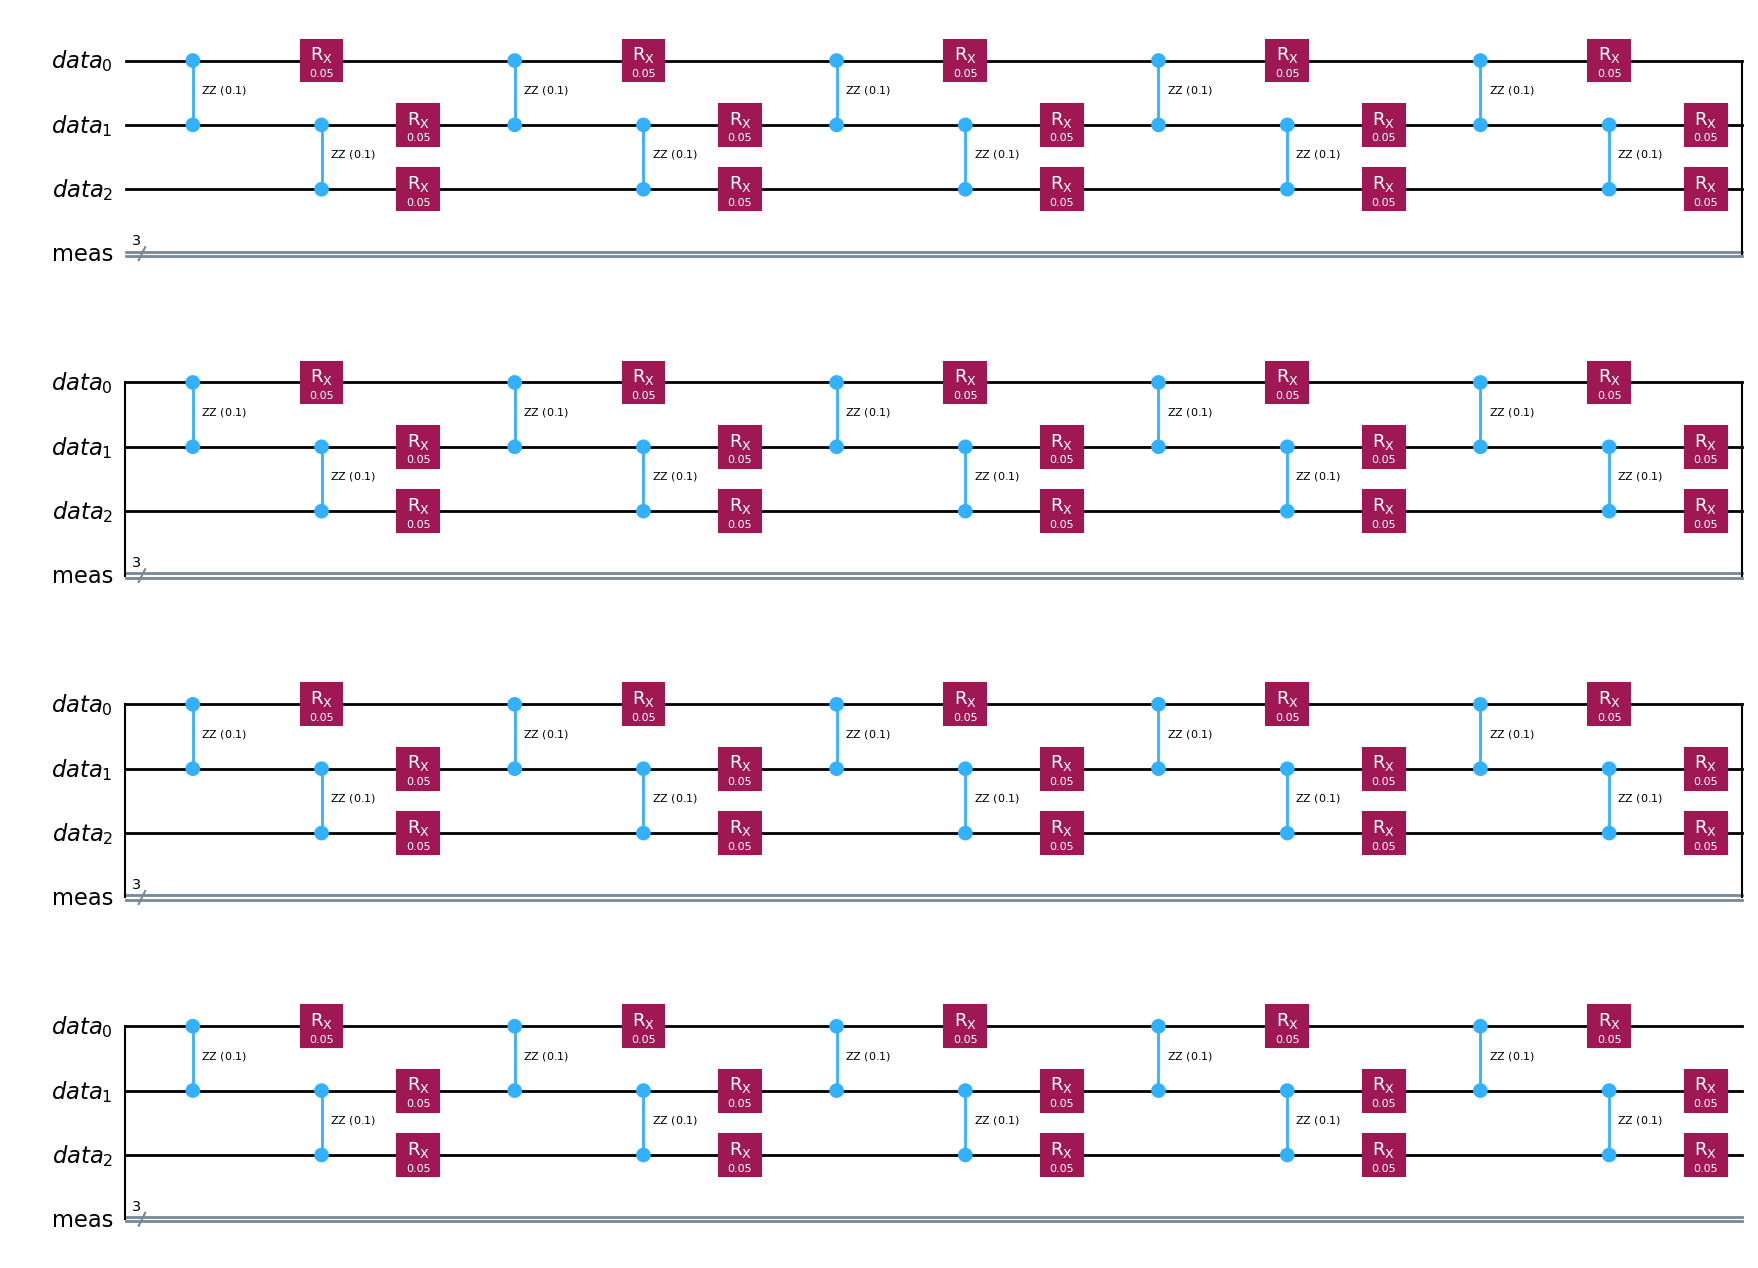

In [5]:
evc = evolution_circuits.unitary_evolve(n, h, final_time, num_timesteps)
evc.draw('mpl')

In [6]:
dc = evolution_circuits.dynamic_evolve(n, h, final_time, num_timesteps, mcm=False)
dc3 = evolution_circuits.dynamic_evolve(n, h, final_time, num_timesteps, mcm=False, folds=3)
dc5 = evolution_circuits.dynamic_evolve(n, h, final_time, num_timesteps, mcm=False, folds=5)
# dc.draw('mpl')

In [7]:
estimator = StatevectorEstimator()

backend = FakeFractionalBackend()
backend_ideal = AerSimulator.from_backend(backend, noise_model=None)

target = backend_ideal.target
pm = generate_preset_pass_manager(optimization_level=3, target=target)

dca = pm.run(dc)
Hdo = Hd.apply_layout(dca.layout)

dca3 = pm.run(dc3)
Hdo3 = Hd.apply_layout(dca3.layout)

dca5 = pm.run(dc5)
Hdo5 = Hd.apply_layout(dca5.layout)

# dca.draw("mpl", scale=0.6, style="iqp", fold=-1, idle_wires=False)

dyn_estimator = EstimatorV2(backend_ideal)

dummy = QuantumCircuit(n)

true_energy = (
    estimator.run([(dummy, H)]).result()[0].data.evs
)

ref_energy = (
    estimator.run([(refc, H)]).result()[0].data.evs
)

brick_energy = (
    estimator.run([(evc, H)]).result()[0].data.evs
)

dynamic_energy = (
    dyn_estimator.run([(dca, Hdo)]).result()[0].data.evs
)

dynamic3_energy = (
    dyn_estimator.run([(dca3, Hdo3)]).result()[0].data.evs
)

dynamic5_energy = (
    dyn_estimator.run([(dca5, Hdo5)]).result()[0].data.evs
)

print(true_energy, ref_energy, brick_energy, dynamic_energy, dynamic3_energy, dynamic5_energy)

2.0 1.9933743452987924 1.9933743452987929 2.017578125 1.99365234375 2.008056640625
